(100000, 29)
(80000, 26)
(20000, 26)
Decision Tree Accuracy: 0.5163
Random Forest Accuracy: 0.56415
XGBoost Accuracy: 0.55235
Accuracy : 0.57205
Precision: 0.5803429988291204
Recall   : 0.7735952993022401
F1 Score : 0.6631773641336429

Confusion Matrix
[[3015 6093]
 [2466 8426]]

Classification Report
              precision    recall  f1-score   support

           0       0.55      0.33      0.41      9108
           1       0.58      0.77      0.66     10892

    accuracy                           0.57     20000
   macro avg       0.57      0.55      0.54     20000
weighted avg       0.57      0.57      0.55     20000

                      Feature  Importance
15       mock_interview_score    0.488741
7        certifications_count    0.420976
5           internships_count    0.325189
6              projects_count    0.288106
17                   backlogs    0.243002
19           leadership_score    0.215405
13               github_repos    0.214622
11    logical_reasoning_score    0

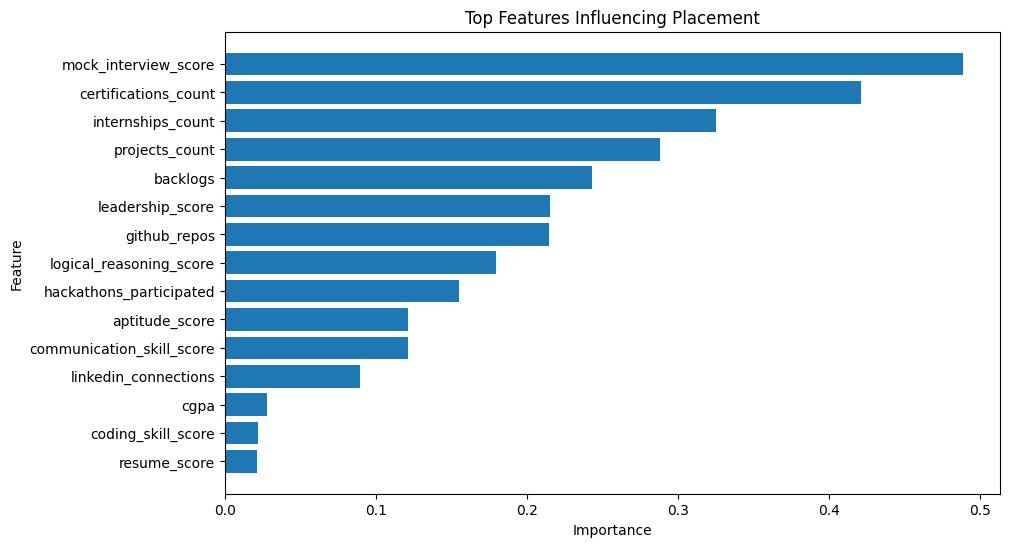

placement_model.pkl saved successfully


In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

df = pd.read_csv("student_placement_prediction_feature_engineered.csv")

print(df.shape)
df.head()

X = df.drop(
    columns=[
        "student_id",
        "placement_status",
        "salary_package_lpa"
    ]
)

y = df["placement_status"]

categorical_cols = X.select_dtypes(include=["object", "string"]).columns

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

import matplotlib.pyplot as plt






model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

model = LogisticRegression(max_iter=3000,random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(model.coef_[0])
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

print(df["placement_status"].value_counts(normalize=True))

plt.title("Top Features Influencing Placement")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()

plt.show()

import joblib

joblib.dump(
    model,
    "placement_model.pkl"
)

print(
    "placement_model.pkl saved successfully"
)